<a href="https://colab.research.google.com/github/2303A52324/AI-ML-Beginner-to-Practitioner/blob/main/Introduction_to_AI_%26_ML_Foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Loading Dataset

In [6]:
df=pd.read_csv("/content/drive/MyDrive/student_dataset.csv")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7
...,...,...,...,...,...,...,...,...,...,...,...
6602,26.0,69.5,High,Medium,No,7.0,80.1,Medium,Yes,1,58.8
6603,23.0,75.9,High,Low,No,6.4,93.2,Low,No,2,67.0
6604,20.1,90.3,High,Low,Yes,7.7,79.4,Medium,Yes,0,58.5
6605,10.3,86.0,High,High,No,6.8,72.1,Medium,Yes,1,58.7


Inspect Dataset

In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (6607, 11)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   float64
 1   Attendance                  6607 non-null   float64
 2   Parental_Involvement        6607 non-null   object 
 3   Access_to_Resources         6607 non-null   object 
 4   Extracurricular_Activities  6607 non-null   object 
 5   Sleep_Hours                 6607 non-null   float64
 6   Previous_Scores             6607 non-null   float64
 7   Motivation_Level            6607 non-null   object 
 8   Internet_Access             6607 non-null   object 
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Final_Exam_Score            6607 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 567.9+ KB


In [9]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Final_Exam_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,20.472726,79.979068,7.185273,74.716059,1.488119,60.400333
std,5.988729,11.547717,1.290241,14.451962,1.216175,8.739400
min,1.100000,60.000000,4.000000,50.000000,0.000000,29.700000
25%,16.500000,70.000000,6.300000,62.100000,1.000000,54.300000
50%,20.500000,79.800000,7.200000,74.600000,1.000000,60.400000
75%,24.500000,90.200000,8.100000,87.400000,2.000000,66.600000
max,44.000000,100.000000,10.000000,100.000000,8.000000,95.200000


In [11]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Final_Exam_Score              0
dtype: int64


In [12]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


Renameing Inconsistent Columns

In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns)

Index(['hours_studied', 'attendance', 'parental_involvement',
       'access_to_resources', 'extracurricular_activities', 'sleep_hours',
       'previous_scores', 'motivation_level', 'internet_access',
       'tutoring_sessions', 'final_exam_score'],
      dtype='object')


Renameing Inconsistent Columns(Numerical Columns)

In [14]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_6723/485167027.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Categorical Columns

In [15]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_6723/2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Removeing Duplicates

In [16]:
df.drop_duplicates(inplace=True)

Verify Cleaning

In [17]:
print(df.isnull().sum())
print("Final Shape:", df.shape)

hours_studied                 0
attendance                    0
parental_involvement          0
access_to_resources           0
extracurricular_activities    0
sleep_hours                   0
previous_scores               0
motivation_level              0
internet_access               0
tutoring_sessions             0
final_exam_score              0
dtype: int64
Final Shape: (6607, 11)


Save Cleaned Dataset

In [18]:
df.to_csv("cleaned_student_exam_scores.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


**Visualize Distributions**
(Distribution of Final Exam Scores)

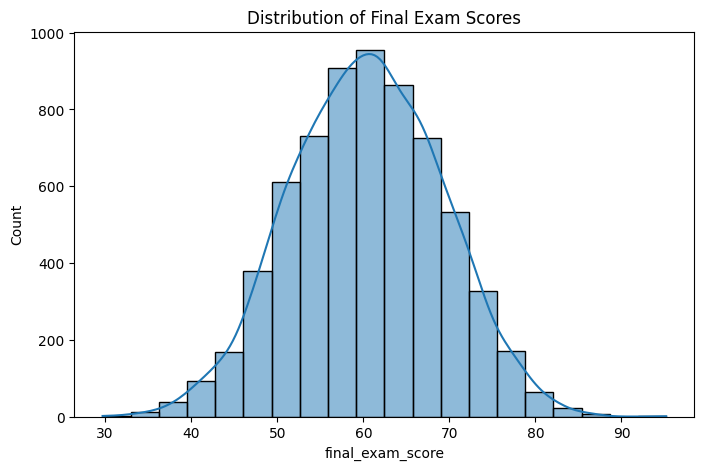

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['final_exam_score'], bins=20, kde=True)
plt.title("Distribution of Final Exam Scores")
plt.show()

Study Hours Distribution

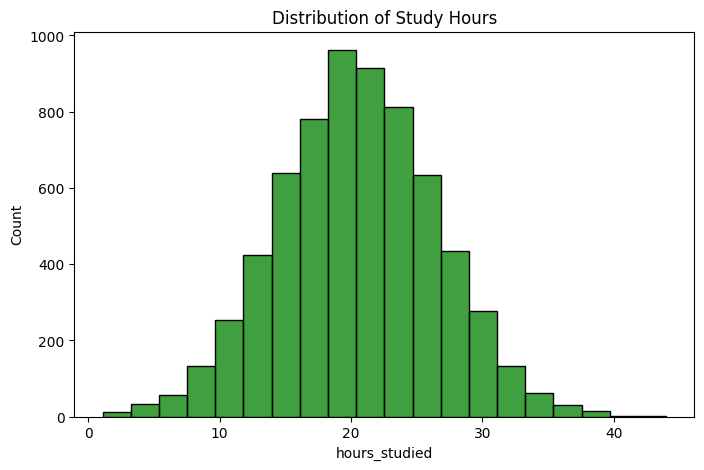

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['hours_studied'], bins=20, color='green')
plt.title("Distribution of Study Hours")
plt.show()

Sleep Hours Distribution

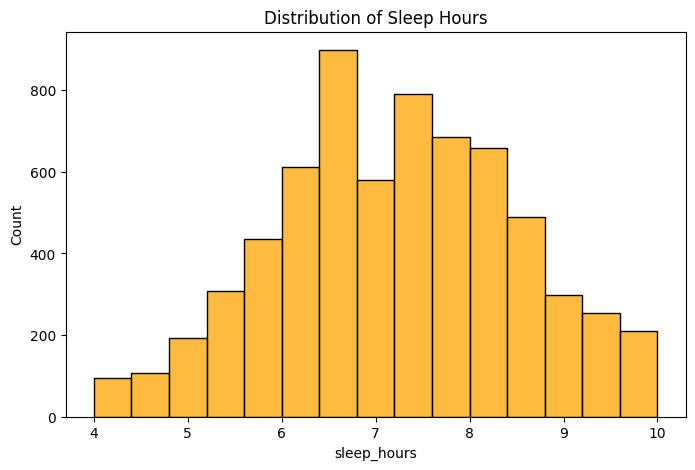

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['sleep_hours'], bins=15, color='orange')
plt.title("Distribution of Sleep Hours")
plt.show()

**Relationship Analysis**
(Study Hours vs Final Score)

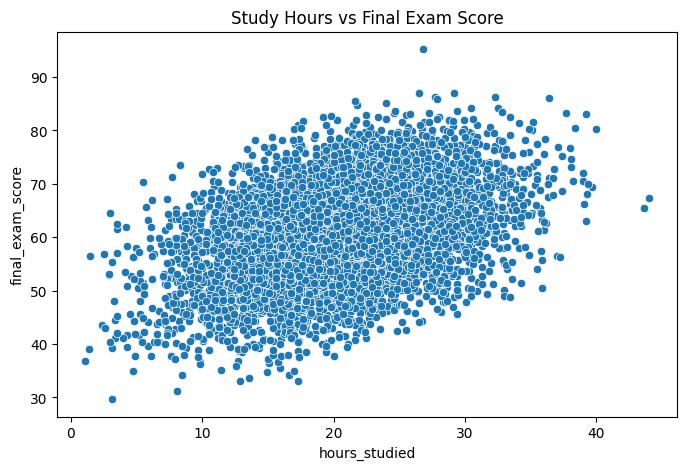

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='hours_studied',
    y='final_exam_score',
    data=df
)
plt.title("Study Hours vs Final Exam Score")
plt.show()

Attendance vs Final Score

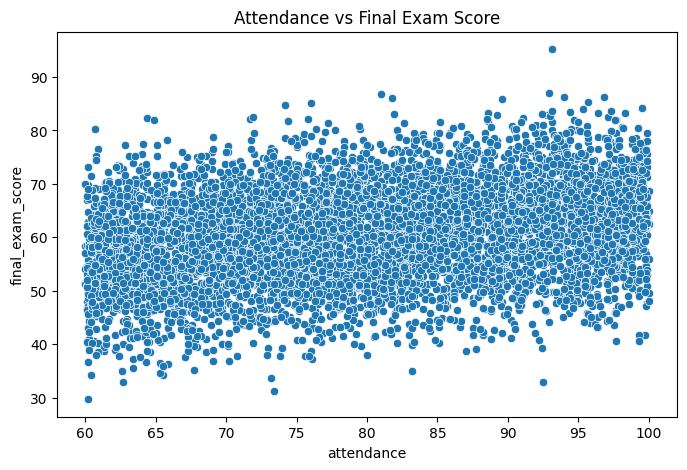

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='attendance',
    y='final_exam_score',
    data=df
)
plt.title("Attendance vs Final Exam Score")
plt.show()

Previous Scores vs Final Score

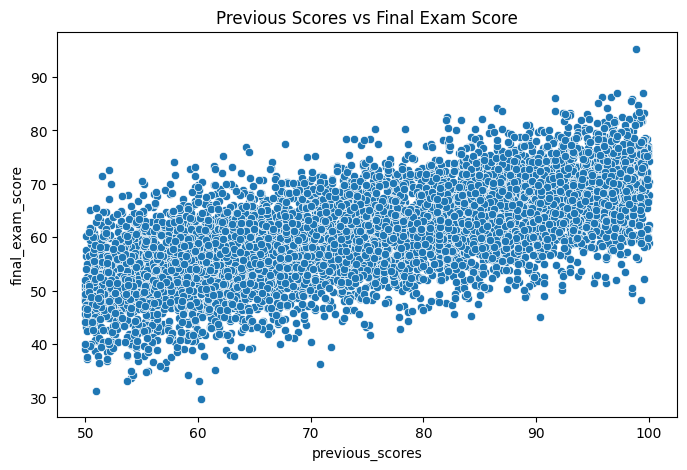

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='previous_scores',
    y='final_exam_score',
    data=df
)
plt.title("Previous Scores vs Final Exam Score")
plt.show()

Correlation Heatmap

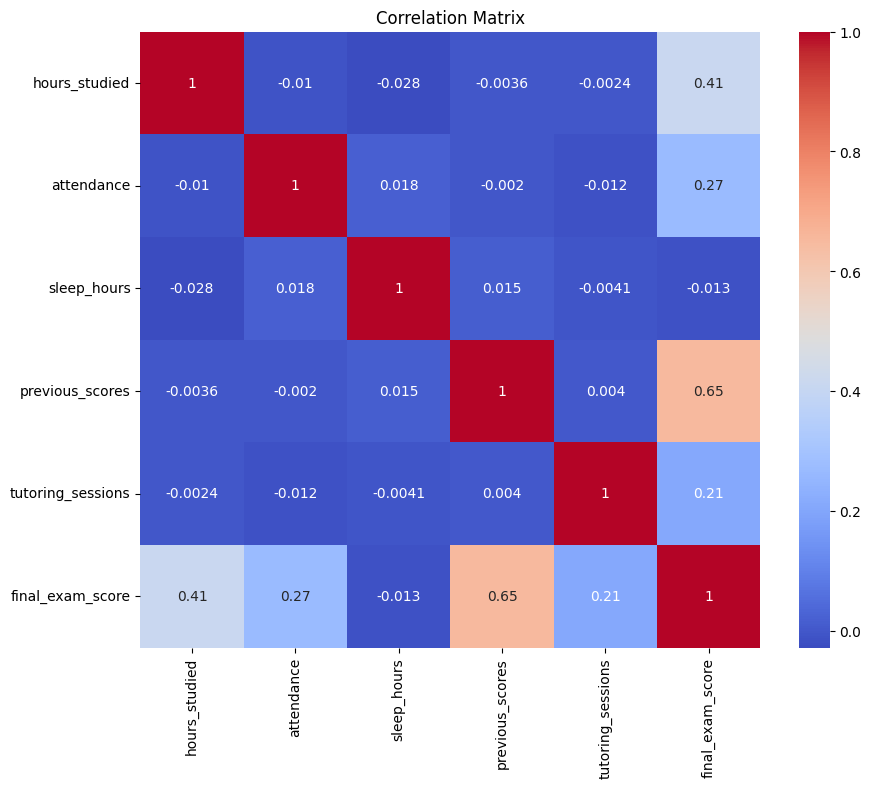

In [25]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

Insights

In [26]:
print("Average Final Score:",
      round(df['final_exam_score'].mean(),2))

print("Average Study Hours:",
      round(df['hours_studied'].mean(),2))

print("Average Attendance:",
      round(df['attendance'].mean(),2))

Average Final Score: 60.4
Average Study Hours: 20.47
Average Attendance: 79.98
